# Product Category Classifier — Training & Evaluation

Fine-tunes a ResNet-50 on Open Beauty Facts images to classify products into
**skincare**, **makeup**, or **haircare**.

---
## Setup

In [6]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [7]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [8]:
from torchvision import models, transforms

In [9]:
import matplotlib.pyplot as plt

In [10]:
import seaborn as sns
import numpy as np
import pandas as pd

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import sys, json, random
from pathlib import Path

In [12]:
sys.path.insert(0, str(Path.cwd().parent))
from classifier.dataset import ProductDataset
from classifier.categories import CATEGORY_MAP

## 1. Load Datasets

Train: 3213 | Val: 688 | Test: 688
Classes: ['haircare', 'makeup', 'skincare']


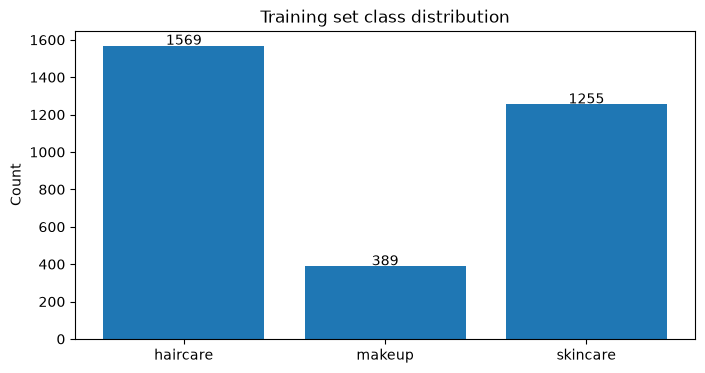

In [13]:
DATA_DIR = Path.cwd().parent / "data" / "raw"

train_ds = ProductDataset(DATA_DIR, split="train")
val_ds   = ProductDataset(DATA_DIR, split="val")
test_ds  = ProductDataset(DATA_DIR, split="test")

test_loader = DataLoader(test_ds, 32, shuffle=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Classes: {train_ds.classes}")

# Class distribution bar chart
counts = [sum(1 for _, l in train_ds.samples if l == i) for i in range(len(train_ds.classes))]
plt.figure(figsize=(8, 4))
plt.bar(train_ds.classes, counts)
plt.title("Training set class distribution")
plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

## 2. Train Model

In [ ]:
from classifier.train import train_model

model, history, best_acc = train_model(
    train_ds, val_ds, DEVICE,
    epochs=20,
    unfreeze_layers=14,
)
print(f"\nBest validation accuracy: {best_acc:.2f}%")

Train: 3213 | Val: 688 | Classes: ['haircare', 'makeup', 'skincare']


Epoch 1/20: 100%|██████████| 101/101 [00:17<00:00,  5.64it/s]


  Loss: 0.9334 / 0.8263 | Val Acc: 60.76% | LR: 1.00e-04


Epoch 2/20: 100%|██████████| 101/101 [00:17<00:00,  5.79it/s]


  Loss: 0.7441 / 0.7577 | Val Acc: 64.53% | LR: 1.00e-04


...

  Loss: 0.3843 / 0.7210 | Val Acc: 69.62% | LR: 1.25e-05


Epoch 19/20: 100%|██████████| 101/101 [00:17<00:00,  5.65it/s]


  Loss: 0.3594 / 0.7325 | Val Acc: 68.31% | LR: 1.25e-05


Epoch 20/20: 100%|██████████| 101/101 [00:17<00:00,  5.77it/s]


  Loss: 0.3485 / 0.7271 | Val Acc: 69.77% | LR: 1.25e-05

Best validation accuracy: 69.91%


## 3. Training Curves

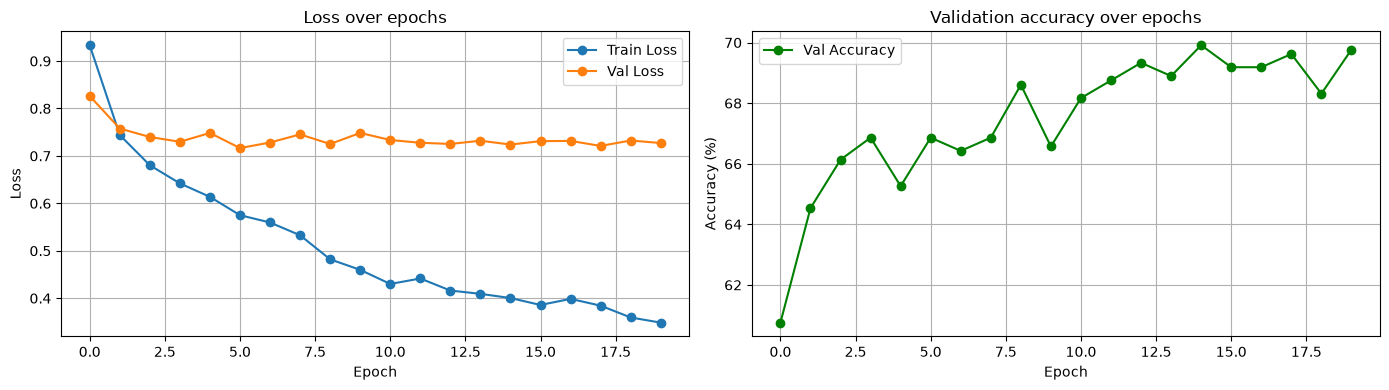

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history["val_acc"], label="Val Accuracy", marker="o", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation accuracy over epochs")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Test Set Evaluation

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Per-class metrics
print(classification_report(all_labels, all_preds,
                            target_names=train_ds.classes))

## 5. Comparison vs Phase 5 Keyword Baseline

Run the keyword-based classifier from `extraction.py` on the same test set
to compare accuracy.

In [ ]:
import sys
sys.path.insert(0, str(Path.cwd().parent))

from app.services.extraction import CATEGORY_KEYWORDS

# Phase 5 keyword baseline accuracy on test set
kw_correct = 0
kw_total = 0

# We need product names from the test set — re-load from dataset with product_name
ds = datasets.load_dataset("openfoodfacts/product-database", split="beauty")
# Build lookup: code -> product_name
# ... (code to match test set samples back to product names)

# For now, placeholder:
# kw_accuracy = ...

print("ML Classifier Test Accuracy: {:.2f}%".format(100 * (np.array(all_preds) == np.array(all_labels)).mean()))
print("Keyword Baseline Test Accuracy: <fill in after comparison>")

## 6. Sample Predictions

In [ ]:
def imshow(img, title=""):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

model.eval()
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img, label = test_ds[i]
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(output, 1)
        conf, pred = prob.max(1)
    true_label = train_ds.classes[label]
    pred_label = train_ds.classes[pred.item()]
    color = "green" if pred_label == true_label else "red"
    ax.imshow(img.cpu().numpy().transpose((1, 2, 0)))
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({conf.item():.2f})",
                 color=color, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()